In [ ]:
# 设置环境变量以离线运行 (一旦权重下载完成)
import os
# 如果已经下载过权重，开启此选项可以跳过连接 Hugging Face
os.environ['HF_HUB_OFFLINE'] = '1' 


# 构建smp.segformer使用resnet50编码器，在WHU的建筑分割数据集进行二分类训练的训练脚本

In [ ]:
# 读取配置文件
import json
with open('D:\\pyLearn\\pyLearn\\test_project\\notebooks\\config\\split_building_config.json', 'r') as f:
    config = json.load(f)
train_data_path = config['data']['train_data_path']
train_labels_path = config['data']['train_labels_path']
test_data_path = config['data']['test_data_path']
test_labels_path = config['data']['test_labels_path']
encoder=config['model']['encoder']
encoder_weights=config['model']['encoder_weights']
channels=config['model']['channels']
classes=config['model']['classes'] 
train_num_workers = config['train']['num_workers']
test_num_workers = config['test']['num_workers']
batch_size=config['data']['batch_size']
train_epochs=config['train']['epochs']
train_learning_rate=config['train']['learning_rate']
train_loss_function=config['train']['loss_function']
train_optimizer=config['train']['optimizer']
activation_cfg = config['model']['activation']
activation = activation_cfg
weight_pth=config['train']['weight_pth']
type=config['model']['type']

In [ ]:
# 根据配置文件构建模型
import segmentation_models_pytorch as smp

# 统一 print 一下当前配置的模型类型，方便调试
# 统一 print 一下当前配置的模型类型，方便调试
print(f"Model type from config: {type}")
train_with_logits = train_loss_function in ['DiceLoss', 'CrossEntropyLoss']
if train_with_logits:
    # For training, keep raw logits and let the loss handle activation.
    print(f"对于训练，使用原始Logits输出，损失函数将自动处理激活,\
          设置的激活函数为: {activation}，仅在测试阶段应用")
    activation = None
if encoder_weights=="None":
    encoder_weights=None
if type == 'Unet':
    model = smp.Unet(encoder_name=encoder, encoder_weights=encoder_weights, in_channels=channels, classes=classes, activation=activation)
elif type == 'FPN':
    model = smp.FPN(encoder_name=encoder, encoder_weights=encoder_weights, in_channels=channels, classes=classes, activation=activation)
elif type == 'Linknet':
    model = smp.Linknet(encoder_name=encoder, encoder_weights=encoder_weights, in_channels=channels, classes=classes, activation=activation)
# 注意：配置文件中写的是 "SegFormer" (大写F)，这里需要匹配字符串
elif type == 'Segformer':
    model = smp.Segformer(encoder_name=encoder, encoder_weights=encoder_weights, in_channels=channels, classes=classes, activation=activation)
elif type == 'PSPNet':
    model = smp.PSPNet(encoder_name=encoder, encoder_weights=encoder_weights, in_channels=channels, classes=classes, activation=activation)
else:
    raise ValueError(f"Unsupported model type: {type}")

Model type from config: Segformer


d:\pytorch\envs\geo_ai\Lib\site-packages\segmentation_models_pytorch\encoders\__init__.py:136: UserWarning: Error loading resnet50 `imagenet` weights from Hugging Face Hub, trying loading from original url...
  warnings.warn(message, UserWarning)


# 构建数据加载器
对于模型训练，需要将数据集整合为一定标准下的dataset以使得数据集能够被dataloder识别并读取进而学习。
故通常对于自建或非经典数据集，需要自行编写一个dataset类
其中dataloder对于dataset的要求为:<br>  
<font color="#FF0000">
__len__()：返回数据集的总样本数（必须实现）。  
__getitem__(index)：根据索引index返回单个样本（必须实现）。<br>
transfrom:用于对数据进行预处理,对于训练集，进行数据增强处理（旋转、裁切）的时候需要注意对img和mask进行一致的操作。  
对于测试集数据，则需要注意不能做增强处理，通常仅执行totenso此类用于将数据转化为模型输入所需形式的任务。
# 注意：如果在transfrom中使用Resize/Crop等几何变换，必须保证image和label同步变换
</font>

只需继承torch.utils.data.Dataset，并重写上述两个方法即可
通常 单个样本 为img+label
对于影像中的目标识别分类任务，单个样本通常为img+mask(+label)的形式，

In [ ]:
# 创建应用于WHU building segmentation的dataset类
import os
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

class building_dataset(Dataset):
    """
    自定义数据集类，用于读取WHU建筑分割数据集
    Args:
        img_dir: 图像文件夹路径
        label_dir: 标签文件夹路径
        transforms: 数据预处理/增强方法 (注意：如果是torchvision transforms，通常只处理image)
    """
    def __init__(self, img_dir, label_dir, transforms=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transforms = transforms
        
        self.img_list = sorted([f for f in os.listdir(img_dir) if f.endswith(('.tif', '.png', '.jpg'))])
        self.label_list = sorted([f for f in os.listdir(label_dir) if f.endswith(('.tif', '.png', '.jpg'))])
        
        assert len(self.img_list) == len(self.label_list), f"Images count ({len(self.img_list)}) and labels count ({len(self.label_list)}) do not match!"

    def __len__(self):
        return len(self.img_list)

    def __getitem__(self, idx):
        img_name = self.img_list[idx]
        label_name = self.label_list[idx]
        
        img_path = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(self.label_dir, label_name)
        
        # 读取
        image = Image.open(img_path).convert("RGB") # 如果不是RGB图像，转换为RGB
        mask = Image.open(label_path) # 保持原始模式，通常为单通道索引图

        # 预处理（最基础操作应当为转化为tensor）
        # 注意：如果使用Resize/Crop等几何变换，必须保证image和label同步变换
        if self.transforms:
            image = self.transforms(image)
        
        # 将label转为Tensor
        # 如果label是PIL图像，需要转为numpy数组再转Tensor，避免自动归一化到[0,1]（如果使用ToTensor的话）
        # 分割标签通常需要LongTensor类型
        mask = np.array(mask)
        # 将mask归一化为0和1 (通常WHU数据集是0和255)
        mask = mask.astype(np.float32)
        mask = mask / 255.0
        mask[mask > 0.5] = 1.0
        mask[mask <= 0.5] = 0.0

        if (train_loss_function == 'CrossEntropyLoss'):
            # CrossEntropyLoss 需要 LongTensor 类型的标签，且标签值为类别索引（0, 1, ...）
            mask = torch.from_numpy(mask).long()
        elif (train_loss_function == 'DiceLoss'):
            mask = torch.from_numpy(mask).float() # 转为float类型，适用于DiceLoss的binary模式
        
        # 如果mask有额外的通道维度（例如 [H, W, 1]），则squeeze掉变成 [H, W]
        # 因为对于DiceLoss的binary模式，标签应该是 [B, H, W] 或 [B, 1, H, W]，而不是 [B, H, W, 1]
        # 但是对于CrossEntropyLoss，标签应该是 [B, H, W]
        # 后续根据损失函数的要求，再在训练函数中进行适当的unsqueeze（例如对DiceLoss的binary模式）
        if len(mask.shape) == 3:
            mask = mask.squeeze(-1)

        return image, mask, img_name

In [ ]:
# 构建数据加载器
from torch.utils.data import DataLoader
from torchvision import transforms

# 修正：ImageFolder适用于分类任务（通过文件夹区分类别），而分割任务通常需要同时读取图像和对应的Mask
# 故此处使用我们自定义的dataset类

# 检查路径，确保指向具体的图像文件夹
# 这里的 train_data_path 应当遵照json中的配置，指向训练集的图像文件夹
train_img_dir = train_data_path
# train_labels_path 在配置文件中通常直接指向 label 文件夹
train_label_dir = train_labels_path 

print(f"Loading training images from: {train_img_dir}")
print(f"Loading training labels from: {train_label_dir}")

# 定义简单的预处理
# 通常分割任务需要专门的数据增强库（如albumentations）来确保image和mask同步变换
# 使用的是标准数据集，故此处仅需要做基本的ToTensor
# 注意：transforms.Compose 接受一个列表
data_transforms = transforms.Compose([
    # 输入的原始影像格式应当为PIL图像，
    # ToTensor会将其转换为 [C, H, W] 的Tensor，并且将像素值归一化到[0,1]
    transforms.ToTensor() 
])

# 实例化 Dataset
train_dataset = building_dataset(train_img_dir, train_label_dir, transforms=data_transforms)
# 实例化 DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 测试读取一个batch
try:
    images, labels, names = next(iter(train_loader))
    print(f"Batch image shape: {images.shape}")
    print(f"Batch label shape: {labels.shape}")
except Exception as e:
    print(f"Error loading batch: {e}")

Loading training images from: D:\pyLearn\test_project\data\whu_cd\train\img
Loading training labels from: D:\pyLearn\test_project\data\whu_cd\train\label
Batch image shape: torch.Size([16, 3, 512, 512])
Batch label shape: torch.Size([16, 512, 512])


# 构建训练函数
训练函数需要包含，数据加载、模型训练、模型前向传播、模型损失函数计算，后向传播梯度下降，参数更新<br>
# 使用tqdm显示当前batch的损失和显存占用，以及训练进度
        进度条会根据训练的进程自动更新，显示当前的batch索引和总batch数，以及当前batch的损失和显存占用
        百分比和剩余时间会根据训练的速度自动计算和显示，帮助你更好地了解训练的进度和资源使用情况 
# 注意： 
    其实际上对于训练而言相当于data_loader的一个增强版本，提供了更友好的训练进度显示和实时更新的功能
    故在使用for对data_loader进行迭代时，需要使用loop来替代原来的data_loader，才能使得loop生效显示进度条和相关信息


# 损失函数定义
# 注意：
   1.对于激活函数，原始代码未考虑到训练时，损失函数内部会自动处理激活，故无需在模型内部做激活，即在配置model时，不需要做激活配置(activation)，设置为none否则会导致损失函数接受的信号错误。<br>
   2.另外softmax和class=1的配置会使得所有数据归为一类，背景与目标混为一类，故应当使用sigmod或修改class。

In [ ]:
# 1. 定义损失函数与迭代优化器
import torch.optim as optim
import torch.nn as nn
import tqdm

# 适合分割任务的损失函数，Dice损失（适用于二分类分割）
# 若为多分类分割，可能需要使用CrossEntropyLoss或者结合DiceLoss和CrossEntropyLoss的混合损失函数
if train_loss_function == 'DiceLoss':
    criterion = smp.losses.DiceLoss(mode='binary')  # 二分类分割
elif train_loss_function == 'CrossEntropyLoss':
    criterion = nn.CrossEntropyLoss()
else:
    print(f"Unsupported loss function specified: {train_loss_function}, defaulting to DiceLoss.")
    criterion = nn.DiceLoss()
# 优化器选择,根据配置文件选择Adam或SGD，默认使用Adam
if train_optimizer == 'adam':
    optimizer = optim.Adam(model.parameters(), lr=train_learning_rate)
elif train_optimizer == 'sgd':
    optimizer = optim.SGD(model.parameters(), lr=train_learning_rate, momentum=0.9)
else:
    print(f"Unsupported optimizer specified: {train_optimizer}, defaulting to Adam.")
    optimizer = optim.Adam(model.parameters(), lr=train_learning_rate)

# 2. 定义训练函数
def train(model,data_loader,criterion,optimizer,device):
    model.train()
    total_loss = 0
    # loop是一个迭代器，使用tqdm包装后会显示进度条,
    # 其实际上对于训练而言相当于data_loader的一个增强版本，提供了更友好的训练进度显示和实时更新的功能
    # 故在使用for对data_loader进行迭代时，需要使用loop来替代原来的data_loader，才能使得loop生效显示进度条和相关信息
    # 使用total显示指定训练数据的总数（以batch为单位，以确保可以对进度条进行计算更新），
    # desc显示当前阶段（训练/测试），postfix显示当前batch的损失和显存占用
    loop = tqdm(data_loader, total=len(data_loader), desc=f"training")
    for batach_index,(images, labels, _) in enumerate(loop):
        images = images.to(device)
        labels = labels.to(device)
        if train_loss_function == 'DiceLoss':
            # DiceLoss的binary模式需要标签形状为 [B, 1, H, W]，且类型为float
            labels = labels.unsqueeze(1).float()
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        # 输出训练进度
        
         # 获取当前显存占用 (单位: GB)
        if torch.cuda.is_available():
            mem_used = torch.cuda.memory_allocated() / 1024**3 
            mem_info = f'{mem_used:.2f}GB'
        else:
            mem_info = 'CPU'
        # 使用tqdm显示当前batch的损失和显存占用，以及训练进度
        # 进度条会根据训练的进程自动更新，显示当前的batch索引和总batch数，以及当前batch的损失和显存占用
        # 百分比和剩余时间会根据训练的速度自动计算和显示，帮助你更好地了解训练的进度和资源使用情况  
        loop.set_postfix(batch_loss=loss.item(), gpu_mem=mem_info)
        # 输出每50个batch的损失
        if (batach_index + 1) % 50 == 0:
            print(f"Batch {batach_index + 1}/{len(data_loader)}, Loss: {loss.item():.4f}")
        
    avg_loss = total_loss / len(data_loader)
    print(f"Total Average training loss: {avg_loss:.4f}")



# 构建测试函数

In [ ]:
# 3. 定义测试函数（可选，后续可以在训练过程中或训练结束后调用）
def test(model,data_loader,criterion,device):
    model.eval()
    total_loss = 0
    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0
    # 定义一个内部函数，根据配置文件中的激活函数设置来应用相应的激活函数
    def _apply_activation(outputs):
        if activation_cfg is None or activation_cfg == "None":
            if train_loss_function == 'DiceLoss':
                return torch.sigmoid(outputs)
            if train_loss_function == 'CrossEntropyLoss':
                return torch.softmax(outputs, dim=1)
            return outputs
        if activation_cfg == 'sigmoid':
            return torch.sigmoid(outputs)
        if activation_cfg == 'softmax':
            return torch.softmax(outputs, dim=1)
        return outputs
    with torch.no_grad():
        for images, labels, _ in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            if train_loss_function == 'DiceLoss':
                labels = labels.unsqueeze(1).float()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            probs = _apply_activation(outputs)
            if probs.dim() == 4 and probs.size(1) > 1:
                # Multi-class logits -> use class-1 probability for binary mask
                probs = probs[:, 1, :, :]
            else:
                probs = probs.squeeze(1)
            preds = (probs > 0.5).float()
            if labels.dim() == 4:
                # 如果标签有额外的通道维度，squeeze掉变成 [B, H, W]
                label_bin = labels.squeeze(1)
            else:
                label_bin = labels.float()

            total_tp += torch.sum((preds == 1) & (label_bin == 1)).item()
            total_fp += torch.sum((preds == 1) & (label_bin == 0)).item()
            total_fn += torch.sum((preds == 0) & (label_bin == 1)).item()
            total_loss += loss.item()
    avg_loss = total_loss / len(data_loader)
    eps = 1e-7
    precision = total_tp / (total_tp + total_fp + eps)
    recall = total_tp / (total_tp + total_fn + eps)
    iou = total_tp / (total_tp + total_fp + total_fn + eps)
    print(f"Total Average testing loss: {avg_loss:.4f}")
    print(f"Test IoU: {iou:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

# 执行模型训练与测试
在 Windows 系统中，PyTorch 的 DataLoader 使用 multiprocessing 启动多进程（当 num_workers > 0 时）采用的是 spawn 模式。  
这意味着子进程会重新导入父进程的主脚本。如果你的训练代码（实例化 DataLoader、模型训练循环等）写在全局作用域而不是 if __name__ == '__main__': 保护块内，子进程在导入脚本时会尝试再次启动训练，导致无限递归或引导错误。

<font color='red'>
在jupyter中，num_workers需要设置为0
<font/>

In [ ]:

# 4. 训练模型
# 这里的 train_data_path 应当遵照json中的配置，指向训练集的图像文件夹
train_img_dir = train_data_path
# train_labels_path 在配置文件中通常直接指向 label 文件夹
train_label_dir = train_labels_path 
data_transforms = transforms.Compose([
    transforms.ToTensor()
])
    

def train_function():
   # 实例化 Dataset
   train_dataset = building_dataset(train_img_dir, train_label_dir, transforms=data_transforms)
   # 实例化 DataLoader
   train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,num_workers=train_num_workers)
   
   device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
   model.to(device)
   num_epochs = train_epochs
   for epoch in range(num_epochs):
       print(f"Epoch {epoch + 1}/{num_epochs}")
       train(model, train_loader, criterion, optimizer, device)
    
   # 训练完成后，可以保存模型权重
   
   torch.save(model.state_dict(), weight_pth)

# 5. 测试模型（可选）
def test_function():
    # 实例化 Dataset
    test_dataset = building_dataset(test_data_path, test_labels_path, transforms=data_transforms)
    # 实例化 DataLoader
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,num_workers=test_num_workers)
    # 加载训练好的模型权重
    model.load_state_dict(torch.load(weight_pth))
    # 将模型移动到GPU（如果可用）
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    test(model, test_loader, criterion, device)

if __name__ == "__main__":
    # 设置环境变量以离线运行 (一旦权重下载完成)
    os.environ['HF_HUB_OFFLINE'] = '1' 
    selection = int(input("Enter 0 to start training, 1 to start testing: "))
    if selection == 0:
       print("Starting training...")
       train_function()
    # 训练完成后，可以调用测试函数评估模型性能
    elif selection == 1:
       print("Starting testing...") 
       test_function()

Epoch 1/20


KeyboardInterrupt: 

# 执行测试集精度评定

In [11]:
import os
if __name__ == "__main__":
    # 设置环境变量以离线运行 (一旦权重下载完成)
    # 如果已经下载过权重，开启此选项可以跳过连接 Hugging Face，直接使用本地缓存
    os.environ['HF_HUB_OFFLINE'] = '1'
    # 实例化 Dataset
    dataset_test=building_dataset(test_data_path, test_labels_path, transforms=data_transforms)
    data_loader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False,num_workers=0) # 注意：测试集通常不需要shuffle，且可以适当增加num_workers以加速数据加载
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    print("Starting testing...")
    test(model, data_loader_test, criterion, device)

Starting testing...


d:\pytorch\envs\geo_ai\Lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Total Average testing loss: 0.9944


# 使用训练好的模型权重，在未切割的原始遥感大图中进行测试


In [13]:
# 使用训练好的模型权重，在大图中进行测试

remote_data_path="D:\\pyLearn\\WHU_build\\split_data\\predict\\2016_train.tif"

# 读取模型配置
# 包括模型类型、编码器、权重、输入通道数、类别数、激活函数等
import json
with open('D:\\pyLearn\\pyLearn\\test_project\\notebooks\\config\\split_building_config.json', 'r') as f:
    config = json.load(f)

type=config['model']['type'] # 模型类型，例如 "Unet", "FPN", "SegFormer" 等
encoder=config['model']['encoder'] # 编码器名称，例如 "resnet34", "mit_b0" 等
encoder_weights=config['model']['encoder_weights'] # 编码器权重，例如 "imagenet" 或 "None"（字符串形式）
channels=config['model']['channels'] # 输入图像的通道数，通常为3（RGB）或4（RGBA），根据数据集实际情况设置
classes=config['model']['classes'] # 输出类别数，对于二分类分割通常设置为1（背景 vs 目标），对于多分类分割则设置为类别总数
activation_cfg = config['model']['activation'] # 激活函数配置，通常为 "sigmoid"（适用于二分类）或 "softmax"（适用于多分类），也可以设置为 "None" 或 None 来表示不使用激活函数（让损失函数处理）
activation = activation_cfg # 训练过程中通常不直接在模型输出上应用激活函数，而是让损失函数（如DiceLoss或CrossEntropyLoss）处理原始Logits输出，因此这里的activation设置为None
model_weight_pth=config['train']['weight_pth']
train_width=config['data']['data_size']['width']
train_height=config['data']['data_size']['height']

# 对于原始遥感影像大图，需要进行裁剪，使得影像尺寸与训练时数据尺寸一致

In [11]:
# 读取原始大图数据
from osgeo import gdal
import numpy as np
import segmentation_models_pytorch as smp
with gdal.Open(remote_data_path) as dataset:
    # 读取图像数据
    image_data = dataset.ReadAsArray()  # 形状通常为 (C, H, W)
    image_shape = image_data.shape # 记录原始图像的形状，方便后续处理和调试

    # 将影像裁剪为训练数据的大小（例如512x512），
    # 原始遥感图像较大，可以使用滑动窗口或其他方法进行裁剪，此处使用滑动窗口
    # 重叠度设置为0.5，以减少最后识别结果中的边界效应
    overlap = 0.5 # 重叠度
    crop_size = (train_height, train_width) # 裁剪大小
    # 根据指定重叠度和裁剪大小计算步长
    step_size = (int(crop_size[0] * (1 - overlap)), int(crop_size[1] * (1 - overlap)))
    # 计算裁剪的起始坐标列表
    crop_coords = []
    for y in range(0, image_shape[1] - crop_size[0] + 1, step_size[0]):
        for x in range(0, image_shape[2] - crop_size[1] + 1, step_size[1]):
            crop_coords.append((x, y))
    # 如果最后的裁剪区域不足以覆盖整个图像，可以添加一个额外的空白裁剪区域来覆盖剩余部分
    if crop_coords[-1][0] + crop_size[1] < image_shape[2]:
        crop_coords.append((image_shape[2] - crop_size[1], crop_coords[-1][1]))
    if crop_coords[-1][1] + crop_size[0] < image_shape[1]:
        crop_coords.append((crop_coords[-1][0], image_shape[1] - crop_size[0]))
    
    # 将裁剪的图像块保存到列表中，方便后续进行模型预测
    cropped_images = []
    for x, y in crop_coords:
        cropped_images.append(image_data[:, y:y+crop_size[0], x:x+crop_size[1]])
    

    # 输出原始图像的形状，确认读取是否正确
    print(f"Original image shape: {image_data.shape}")

Original image shape: (3, 15354, 21243)


In [14]:
# 配置模型
# 统一 print 一下当前配置的模型类型，方便调试
print(f"Model type from config: {type}")

if type == 'Unet':
    model = smp.Unet(encoder_name=encoder, encoder_weights=encoder_weights, in_channels=channels, classes=classes, activation=activation)
elif type == 'FPN':
    model = smp.FPN(encoder_name=encoder, encoder_weights=encoder_weights, in_channels=channels, classes=classes, activation=activation)
elif type == 'Linknet':
    model = smp.Linknet(encoder_name=encoder, encoder_weights=encoder_weights, in_channels=channels, classes=classes, activation=activation)
elif type == 'Segformer':
    model = smp.Segformer(encoder_name=encoder, encoder_weights=encoder_weights, in_channels=channels, classes=classes, activation=activation)
elif type == 'PSPNet':
    model = smp.PSPNet(encoder_name=encoder, encoder_weights=encoder_weights, in_channels=channels, classes=classes, activation=activation)
else:
    raise ValueError(f"Unsupported model type: {type}")

def _apply_activation(outputs):
    if activation_cfg is None or activation_cfg == "None":
        if train_loss_function == 'DiceLoss':
            return torch.sigmoid(outputs)
        if train_loss_function == 'CrossEntropyLoss':
            return torch.softmax(outputs, dim=1)
        return outputs
    if activation_cfg == 'sigmoid':
        return torch.sigmoid(outputs)
    if activation_cfg == 'softmax':
        return torch.softmax(outputs, dim=1)
    return outputs
# 加载训练好的模型权重
model.load_state_dict(torch.load(model_weight_pth))
# 将模型移动到GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


Model type from config: Segformer


Segformer(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
 

# 编写预测函数，用于获取原始影像并进行预测

In [15]:
# 将影像整理为模型输入的格式，并进行预测
import torch
import torch.nn as nn

# 对cropped_images中的每个图像块进行预测
predictions = []
# 对于每个裁剪的图像块，进行预处理并输入模型进行预测
for idx, cropped_image in enumerate(cropped_images):
    tensor_data=torch.from_numpy(cropped_image).float() # 转为float类型的Tensor，适用于模型输入
    tensor_data = tensor_data.unsqueeze(0) # 添加batch维度，变为 [1, C, H, W]
    tensor_data = tensor_data.to(device) # 将数据移动到GPU（如果可用）
    with torch.no_grad():
        output = model(tensor_data) # 模型输出，形状通常为 [1, classes, H, W]
        # 根据配置文件中的激活函数设置来应用相应的激活函数,获得概率图
        probs = _apply_activation(output) 
        # 对于二分类分割，通常会得到 [1, 1, H, W] 的概率图，表示每个像素属于建筑的概率
        if probs.dim() == 4 and probs.size(1) > 1:
            # Multi-class logits -> use class-1 probability for binary mask
            probs = probs[:, 1, :, :]
        else:
            probs = probs.squeeze(1) # 如果是单通道输出，去掉通道维度，变为 [1, H, W]
        
        pred=(probs > 0.5).float() # 二分类分割的预测结果，形状为 [1, H, W]，值为0或1
        predictions.append(pred.cpu().numpy()) # 将预测结果移动到CPU并转为numpy数组，方便后续处理

# 将预测结果进行后处理，例如拼接成完整的分割图，保存为文件等
# 拼接
# 将所有预测块按坐标加权拼接（重叠区域取平均）
full_pred_sum = np.zeros((image_shape[1], image_shape[2]), dtype=np.float32)
full_pred_count = np.zeros((image_shape[1], image_shape[2]), dtype=np.float32)

for (x, y), pred in zip(crop_coords, predictions):
    pred_patch = np.squeeze(pred).astype(np.float32)  # [H, W]
    h, w = pred_patch.shape
    full_pred_sum[y:y+h, x:x+w] += pred_patch
    full_pred_count[y:y+h, x:x+w] += 1.0

# 避免除零
full_pred_count[full_pred_count == 0] = 1.0

# 重叠区域平均后再二值化
full_pred_prob = full_pred_sum / full_pred_count
stitched_mask = (full_pred_prob > 0.5).astype(np.uint8)

print(f"Stitched mask shape: {stitched_mask.shape}")
print(f"Foreground ratio: {stitched_mask.mean():.4f}")

Tensor data shape before moving to device: torch.Size([1, 3, 512, 512])
Model output shape: torch.Size([1, 1, 512, 512])
Tensor data shape before moving to device: torch.Size([1, 3, 512, 512])
Model output shape: torch.Size([1, 1, 512, 512])
Tensor data shape before moving to device: torch.Size([1, 3, 512, 512])
Model output shape: torch.Size([1, 1, 512, 512])
Tensor data shape before moving to device: torch.Size([1, 3, 512, 512])
Model output shape: torch.Size([1, 1, 512, 512])
Tensor data shape before moving to device: torch.Size([1, 3, 512, 512])
Model output shape: torch.Size([1, 1, 512, 512])
Tensor data shape before moving to device: torch.Size([1, 3, 512, 512])
Model output shape: torch.Size([1, 1, 512, 512])
Tensor data shape before moving to device: torch.Size([1, 3, 512, 512])
Model output shape: torch.Size([1, 1, 512, 512])
Tensor data shape before moving to device: torch.Size([1, 3, 512, 512])
Model output shape: torch.Size([1, 1, 512, 512])
Tensor data shape before moving 

# 对预测结果进行可视化

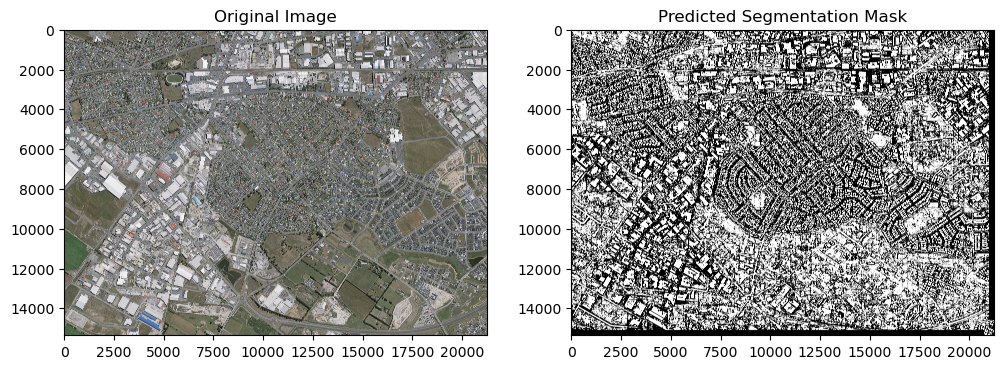

: 

In [ ]:
# 对于预测结果进行可视化，输出两幅影像，左侧为原始影像，右侧为预测的分割结果
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# 原始影像（取RGB通道）
axes[0].imshow(image_data[:3, :, :].transpose(1, 2, 0).astype(np.uint8)) # 转为 [H, W, C] 格式并显示
axes[0].set_title("Original Image")
# 预测的分割结果
axes[1].imshow(stitched_mask, cmap='gray') # 显示二值分割结果
axes[1].set_title("Predicted Segmentation Mask")

# 保存可视化结果
plt.savefig("D:\\pyLearn\\WHU_build\\split_data\\predict\\result\\segmentation_result.png")
plt.show()